# Tutorial 5: Running Inference with Multiprocessing

This tutorial demonstrates how to run inference using `mp_inference.run()`, the multiprocessing
drop-in for `inference.run()`.  We run serial and MP inference on the same event and bank,
then compare posteriors and timing.

## What changes vs serial (`inference.run_and_profile`)

| Stage | Serial | MP |
|-------|--------|----|
| 1 – Setup | serial | serial |
| 2 – Incoherent | serial batches | **Pool over bank chunks** |
| 3 – Cross-bank cut | serial | serial |
| 4 – Extrinsic | serial | serial (or parallel with `n_ext_workers>1`) |
| 5 – Coherent | serial i_blocks | **Pool, one worker per i_block (thin)** |
| 6 – Postprocess | serial | serial |

Expected speedup: ~`n_workers`× on the coherent stage, moderate gain on incoherent.

In [2]:
# Cell 1 — env vars MUST come before any numpy/scipy import
import os
os.environ["OMP_NUM_THREADS"]      = "1"
os.environ["MKL_NUM_THREADS"]      = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"]  = "1"

In [3]:
import sys
import time
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

sys.path.append("../..")

from cogwheel import data, gw_utils, gw_plotting, utils, prior_ratio
from cogwheel.gw_prior import IntrinsicIASPrior
from dot_pe import inference, mp_inference, config, waveform_banks
from dot_pe.power_law_mass_prior import PowerLawIntrinsicIASPrior

ARTIFACTS_DIR = Path("./artifacts_mp")
ARTIFACTS_DIR.mkdir(exist_ok=True)
print("Imports OK")

Imports OK


## Step 1: Create event and bank

Same injection as notebook 03 — reuses existing artifacts if already present.

In [4]:
eventname = "tutorial_mp_event"
chirp_mass = 20.0
q = 0.7
m1, m2 = gw_utils.mchirpeta_to_m1m2(chirp_mass, gw_utils.q_to_eta(q))

injection_par_dic = dict(
    m1=m1,
    m2=m2,
    ra=0.5,
    dec=0.5,
    iota=np.pi / 3,
    psi=1.0,
    phi_ref=12.0,
    s1z=0.3,
    s2z=0.3,
    s1x_n=0.1,
    s1y_n=0.2,
    s2x_n=0.3,
    s2y_n=-0.2,
    l1=0.0,
    l2=0.0,
    tgps=0.0,
    f_ref=50.0,
    d_luminosity=2000.0,
    t_geocenter=0.0,
)

event_path = ARTIFACTS_DIR / f"{eventname}.npz"
if not event_path.exists():
    event_data = data.EventData.gaussian_noise(
        eventname=eventname,
        detector_names="HLV",
        duration=120.0,
        asd_funcs=["asd_H_O3", "asd_L_O3", "asd_V_O3"],
        tgps=0.0,
        fmax=1600.0,
        seed=20260314,
    )
    event_data.inject_signal(injection_par_dic, "IMRPhenomXPHM")
    snr = np.sqrt(
        2 * (event_data.injection["d_h"] - 0.5 * event_data.injection["h_h"]).sum()
    )
    print(f"Injection SNR: {snr:.2f}")
    event_data.to_npz(filename=event_path, overwrite=True)
    print(f"Saved event: {event_path}")
else:
    print(f"Reusing existing event: {event_path}")

Reusing existing event: artifacts_mp/tutorial_mp_event.npz


In [5]:
bank_dir   = ARTIFACTS_DIR / "bank"
bank_size  = 2**16
mchirp_min, mchirp_max = 15, 30
q_min      = 0.2
f_ref      = 50.0
seed_bank  = 777
approximant = "IMRPhenomXPHM"

if not (bank_dir / "intrinsic_sample_bank.feather").exists():
    bank_dir.mkdir(parents=True, exist_ok=True)

    powerlaw_prior = PowerLawIntrinsicIASPrior(
        mchirp_range=(mchirp_min, mchirp_max), q_min=q_min, f_ref=f_ref,
    )
    ias_prior = IntrinsicIASPrior(
        mchirp_range=(mchirp_min, mchirp_max), q_min=q_min, f_ref=f_ref,
    )
    pr_ratio = prior_ratio.PriorRatio(ias_prior, powerlaw_prior)
    prior_ratio._remove_matching_items(
        pr_ratio._numerator_subpriors, pr_ratio._denominator_subpriors
    )

    print(f"Generating {bank_size:,} bank samples...")
    bank_samples = powerlaw_prior.generate_random_samples(bank_size, seed=seed_bank, return_lnz=False)
    bank_samples["mchirp"]  = gw_utils.m1m2_to_mchirp(bank_samples["m1"], bank_samples["m2"])
    bank_samples["lnq"]     = np.log(bank_samples["m2"] / bank_samples["m1"])
    bank_samples["chieff"]  = gw_utils.chieff(*bank_samples[["m1", "m2", "s1z", "s2z"]].values.T)
    bank_samples["log_prior_weights"] = bank_samples.apply(
        lambda row: pr_ratio.ln_prior_ratio(**row.to_dict()), axis=1
    )

    bank_columns = ["m1", "m2", "s1z", "s1x_n", "s1y_n", "s2z", "s2x_n", "s2y_n", "iota", "log_prior_weights"]
    samples_path = bank_dir / "intrinsic_sample_bank.feather"
    bank_samples[bank_columns].to_feather(samples_path)

    bank_config = {
        "bank_size": bank_size,
        "mchirp_min": mchirp_min, "mchirp_max": mchirp_max,
        "q_min": q_min, "f_ref": f_ref,
        "fbin": config.DEFAULT_FBIN.tolist(),
        "approximant": approximant,
        "m_arr": [2, 1, 3, 4],
        "seed": seed_bank,
    }
    with open(bank_dir / "bank_config.json", "w") as f:
        json.dump(bank_config, f, indent=4)

    print(f"Generating waveforms (4 cores)...")
    waveform_banks.create_waveform_bank_from_samples(
        samples_path=samples_path,
        bank_config_path=bank_dir / "bank_config.json",
        waveform_dir=bank_dir / "waveforms",
        n_pool=4, blocksize=4096, approximant=approximant,
    )
    print("Bank ready.")
else:
    print(f"Reusing existing bank: {bank_dir}")

Reusing existing bank: artifacts_mp/bank


## Step 2: Serial baseline

In [5]:
N_EXT = 1024
N_PHI = 50
N_T = 128
SEED = 42
MCHIRP = chirp_mass
BS = 2048

serial_rundir_root = ARTIFACTS_DIR / "run_serial"
serial_rundir_root.mkdir(exist_ok=True)

t_serial_start = time.time()
serial_rundir = inference.run_and_profile(
    event=event_path,
    bank_folder=bank_dir,
    n_ext=N_EXT,
    n_phi=N_PHI,
    n_t=N_T,
    blocksize=BS,
    single_detector_blocksize=BS,
    seed=SEED,
    event_dir=str(serial_rundir_root),
    mchirp_guess=MCHIRP,
    max_incoherent_lnlike_drop=20,
    max_bestfit_lnlike_diff=20,
    draw_subset=True,
)
t_serial = time.time() - t_serial_start

serial_summary = utils.read_json(serial_rundir / "summary_results.json")
print(f"\nSerial wall time : {t_serial:.1f} s")
print(f"ln_evidence      : {serial_summary['ln_evidence']:.4f}")
print(f"n_effective      : {serial_summary['n_effective']:.1f}")

Setting paths & loading configurations...
Creating COGWHEEL objects...
Searching incoherent solution for tutorial_mp_event
Set intrinsic parameters, lnL = 35.666042112947835
Set time, lnL(L) = 16.28765355168229
Set sky location, lnL = 29.25207352033209
Set phase and distance, lnL = 29.25207352033209
Set mchirp_range = (np.float64(16.29839134730849), np.float64(41.7178740401165))
Running inference with 1 bank(s)

=== Incoherent selection per bank ===

Processing bank: bank_0


Processing intrinsic batches: 100%|██████████| 32/32 [02:08<00:00,  4.01s/it]


Bank bank_0: 65536 intrinsic samples evaluated.

=== Cross-bank threshold selection ===
Global maximum incoherent lnlike: 45.25
Global threshold: 25.25
Bank bank_0: 22608 intrinsic samples passed global threshold.

=== Extrinsic sample generation ===
Generating extrinsic samples (global, multibank)...


2026-03-14 23:37:48 - Getting 16 MarginalizationInfo objects from 1 banks.
Marginalization objects: 100%|██████████| 16/16 [00:07<00:00,  2.05obj/s, batches=1/23, accepted=16/16]
2026-03-14 23:38:00 - MarginalizationInfo object created!
2026-03-14 23:38:00 - Saving MarginalizationInfo object to artifacts_mp/run_serial/run_0.



=== Coherent inference per bank ===

Processing bank: bank_0
Creating 12 x 1 likelihood blocks...


Coherent likelihood blocks: 100%|██████████| 12/12 [11:58<00:00, 59.85s/it]



=== Combining results ===

Combining prob_samples across banks...
Standardizing samples...
Standardizing samples done in 0.557 seconds.
Saving samples to file...
Samples saved to:
 artifacts_mp/run_serial/run_0/samples.feather

Serial wall time : 993.4 s
ln_evidence      : -0.4474
n_effective      : 2704.6


## Step 3: MP run with `mp_inference.run()`

### Memory budget for the coherent stage

Each thin coherent worker allocates two dominant arrays (`dh_ieo` and `hh_ieo`),
both of shape `(blocksize, n_ext, n_phi)` in `complex128` (16 bytes each):

```
per-worker = 2 × blocksize × N_EXT × N_PHI × 16 bytes
peak total ≈ N_WORKERS × per-worker  +  ~5 GB (parent + precompute + Python heap)
```

**Rule of thumb:** keep `N_WORKERS × 2 × BS × N_EXT × N_PHI × 16 B < 85 % of RAM`.

With `BS=2048`, `N_EXT=1024`, `N_PHI=50`, `N_WORKERS=8` the estimate is ~37 GB of
worker arrays alone, pushing a 40 GB kernel over its limit.  `BS=512` reduces that
to ~9 GB total — safe on any modern laptop or compute node.

The cell below prints the estimate for the parameters chosen above.

In [6]:
# Memory estimate — coherent stage
# Uses the same BS / N_EXT / N_PHI / N_WORKERS defined in the MP cell below.
_BS, _N_EXT, _N_PHI, _N_WORKERS = 512, 1024, 50, 8
MEM_BUDGET_GB = 40          # available RAM (GB); adjust if your machine differs

bytes_per_worker = 2 * _BS * _N_EXT * _N_PHI * 16   # dh_ieo + hh_ieo, complex128
gb_workers  = _N_WORKERS * bytes_per_worker / 1e9
gb_overhead = 5.0                                     # parent + precompute + Python heap
gb_total    = gb_workers + gb_overhead

status = "OK" if gb_total < MEM_BUDGET_GB * 0.85 else "WARNING — may OOM"
print(f"Per-worker coherent arrays : {bytes_per_worker/1e9:.2f} GB")
print(f"All {_N_WORKERS} workers            : {gb_workers:.1f} GB")
print(f"+ overhead (~5 GB)         : {gb_overhead:.1f} GB")
print(f"Estimated total            : {gb_total:.1f} / {MEM_BUDGET_GB} GB  [{status}]")

Per-worker coherent arrays : 0.84 GB
All 8 workers            : 6.7 GB
+ overhead (~5 GB)         : 5.0 GB
Estimated total            : 11.7 / 40 GB  [OK]


In [7]:
N_EXT = 1024
N_PHI = 50
N_T = 128
SEED = 42
MCHIRP = chirp_mass
BS = 512
N_WORKERS = 8

mp_rundir_root = ARTIFACTS_DIR / "run_mp"
mp_rundir_root.mkdir(exist_ok=True)

t_mp_start = time.time()
mp_rundir = mp_inference.run(
    event=event_path,
    bank_folder=bank_dir,
    n_ext=N_EXT,
    n_phi=N_PHI,
    n_t=N_T,
    blocksize=BS,
    single_detector_blocksize=BS,
    n_workers=N_WORKERS,
    n_ext_workers=1,
    seed=SEED,
    event_dir=str(mp_rundir_root),
    mchirp_guess=MCHIRP,
    max_incoherent_lnlike_drop=20,
    max_bestfit_lnlike_diff=20,
    draw_subset=True,
)
t_mp = time.time() - t_mp_start

mp_summary = utils.read_json(mp_rundir / "summary_results.json")
print(f"\nMP wall time ({N_WORKERS} workers) : {t_mp:.1f} s")
print(f"ln_evidence                    : {mp_summary['ln_evidence']:.4f}")
print(f"n_effective                    : {mp_summary['n_effective']:.1f}")

[MP] n_workers = 8
Setting paths & loading configurations...
Creating COGWHEEL objects...
Searching incoherent solution for tutorial_mp_event
Set intrinsic parameters, lnL = 35.666042112947835
Set time, lnL(L) = 16.28765355168229
Set sky location, lnL = 29.25207352033209
Set phase and distance, lnL = 29.25207352033209
Set mchirp_range = (np.float64(16.29839134730849), np.float64(41.7178740401165))
Running inference with 1 bank(s)
  [RSS] after Stage 1 + del coherent_posterior: cur=576 MB  peak=3042 MB

=== Incoherent selection per bank (MP) ===

Processing bank: bank_0
  [MP] incoherent: 8 chunks -> 8 workers


incoherent chunks: 100%|██████████| 8/8 [00:39<00:00,  4.93s/it]


Bank bank_0: 65536 intrinsic samples evaluated.
  [RSS] after Stage 2 incoherent + gc/trim: cur=579 MB  peak=3042 MB

=== Cross-bank threshold selection ===
Global maximum incoherent lnlike: 45.25
Global threshold: 25.25
Bank bank_0: 22608 intrinsic samples passed global threshold.

=== Extrinsic sample generation ===
Generating extrinsic samples (global, multibank)...


2026-03-15 00:29:56 - Getting 16 MarginalizationInfo objects from 1 banks.
Marginalization objects: 100%|██████████| 16/16 [00:07<00:00,  2.08obj/s, batches=1/23, accepted=16/16]
2026-03-15 00:30:07 - MarginalizationInfo object created!
2026-03-15 00:30:08 - Saving MarginalizationInfo object to artifacts_mp/run_mp/run_3.


  [RSS] after Stage 4 extrinsic + gc/trim: cur=613 MB  peak=3634 MB

=== Coherent inference per bank (MP, thin workers) ===

Processing bank: bank_0
  [MP] pre-computing coherent setup for bank bank_0...
  [thin] pre-computing dt_linfree for 22608 selected indices...
  [thin] coherent setup saved to artifacts_mp/run_mp/run_3/mp_coherent_setup_bank_0
  [RSS] after precompute + gc/trim (before coherent pool): cur=623 MB  peak=3634 MB
  [RSS] after load_thin_setup (coherent Pool fork point): cur=643 MB  peak=3634 MB
  [MP] coherent: 45 i_blocks -> 8 workers


coherent i_blocks: 100%|██████████| 45/45 [01:17<00:00,  1.71s/it]



=== Combining results ===

Combining prob_samples across banks...
Standardizing samples...
Standardizing samples done in 0.392 seconds.
Saving samples to file...
Samples saved to:
 artifacts_mp/run_mp/run_3/samples.feather

Total wall-clock time: 256.0 s

MP wall time (8 workers) : 256.0 s
ln_evidence                    : -0.4468
n_effective                    : 2707.8


/home/projects/barakz/jonatahm/dot-pe-future/notebooks/05_run_inference_mp/../../dot_pe/inference.py:1540: UserWarning: No CoherentLikelihoodProcessor.json found; skipping injection comparison
  warnings.warn(


## Step 4: Comparison table

In [ ]:
rows = [
    {"mode": "serial",          "n_workers": 1,         "wall_s": t_serial,
     "ln_evidence": serial_summary["ln_evidence"],
     "n_effective": serial_summary["n_effective"],
     "n_effective_i": serial_summary["n_effective_i"],
     "n_effective_e": serial_summary["n_effective_e"]},
    {"mode": f"mp",              "n_workers": N_WORKERS, "wall_s": t_mp,
     "ln_evidence": mp_summary["ln_evidence"],
     "n_effective": mp_summary["n_effective"],
     "n_effective_i": mp_summary["n_effective_i"],
     "n_effective_e": mp_summary["n_effective_e"]},
]
df_cmp = pd.DataFrame(rows).set_index("mode")
df_cmp["speedup"] = t_serial / df_cmp["wall_s"]
df_cmp["ln_evidence_diff"] = df_cmp["ln_evidence"] - serial_summary["ln_evidence"]

display(df_cmp.round(3))

## Step 5: Corner plot — serial vs MP

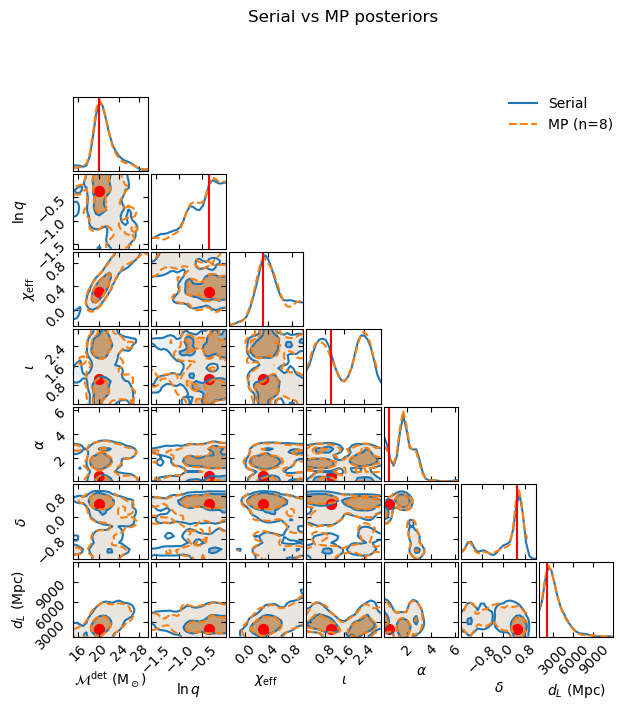

In [10]:
true_mchirp = gw_utils.m1m2_to_mchirp(
    injection_par_dic["m1"], injection_par_dic["m2"]
)
true_lnq = np.log(injection_par_dic["m2"] / injection_par_dic["m1"])
true_chieff = gw_utils.chieff(
    injection_par_dic["m1"],
    injection_par_dic["m2"],
    injection_par_dic["s1z"],
    injection_par_dic["s2z"],
)
true_values = injection_par_dic | {
    "mchirp": true_mchirp,
    "lnq": true_lnq,
    "chieff": true_chieff,
}
serial_rundir = Path(
    "/home/projects/barakz/jonatahm/dot-pe-future/notebooks/05_run_inference_mp/artifacts_mp/run_serial/run_0"
)
serial_samples = pd.read_feather(serial_rundir / "samples.feather")
mp_samples = pd.read_feather(mp_rundir / "samples.feather")

params = ["mchirp", "lnq", "chieff", "iota", "ra", "dec", "d_luminosity"]

corner_plot = gw_plotting.MultiCornerPlot(
    [serial_samples, mp_samples],
    params=params,
    smooth=1.0,
    labels=["Serial", f"MP (n={N_WORKERS})"],
)
corner_plot.plot(max_figsize=7)
corner_plot.scatter_points(
    true_values, colors="red", marker=".", s=200, label="Injection"
)
plt.suptitle("Serial vs MP posteriors", y=1.01)
plt.show()

## Step 6: Profiling smoke-test

Verify that `mp_inference.run_and_profile()` writes per-worker `.prof` files and a merged report.
Uses a tiny subset (`n_int=512`, `n_ext=128`) so it finishes in under a minute.

In [ ]:
prof_rundir = mp_inference.run_and_profile(
    event=event_path,
    bank_folder=bank_dir,
    n_ext=128,
    n_phi=N_PHI,
    n_t=N_T,
    n_int=512,
    blocksize=BS,
    single_detector_blocksize=BS,
    n_workers=4,
    n_ext_workers=1,
    seed=SEED,
    event_dir=str(ARTIFACTS_DIR / "run_mp_profile"),
    mchirp_guess=MCHIRP,
    draw_subset=False,
)

prof_files = list((prof_rundir / "worker_profiles").glob("*.prof"))
assert len(prof_files) > 0, "No per-worker .prof files written"
assert (prof_rundir / "profile_output.prof").exists(), "Missing merged profile_output.prof"
assert (prof_rundir / "profile_output.txt").exists(), "Missing profile_output.txt"

with open(prof_rundir / "profile_output.txt") as f:
    print("".join(f.readlines()[:30]))

print(f"Profiling OK: {len(prof_files)} worker .prof files in {prof_rundir / 'worker_profiles'}")